In [1]:
import numpy as np
import matplotlib.pyplot as plt
# sphinx_gallery_thumbnail_path = '_static/playback-thumbnail.png'

import librosa

# We'll need IPython.display's Audio widget
from IPython.display import Audio

# We'll also use `mir_eval` to synthesize a signal for us
!pip install mir_eval

import mir_eval.sonify

# playing a synthetic song
sr = 22050

# create audio data
y_sweep = librosa.chirp(fmin=librosa.note_to_hz('C3'),
                        fmax=librosa.note_to_hz('C5'),
                        sr=sr,
                        duration=1)

Audio(data=y_sweep, rate=sr)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mir_eval: filename=mir_eval-0.7-py3-none-any.whl size=100699 sha256=62cd361b54a2581b4e238b501a9b3a4207c962e286f6c172f04fdf8b95728a5a
  Stored in directory: /root/.cache/pip/wheels/7a/37/52/2a4c9f90d1b3414709ae2fe4627b3c13894f8922d3aade1f9e
Successfully built mir_eval


# Task 1: sampling frequency sr change

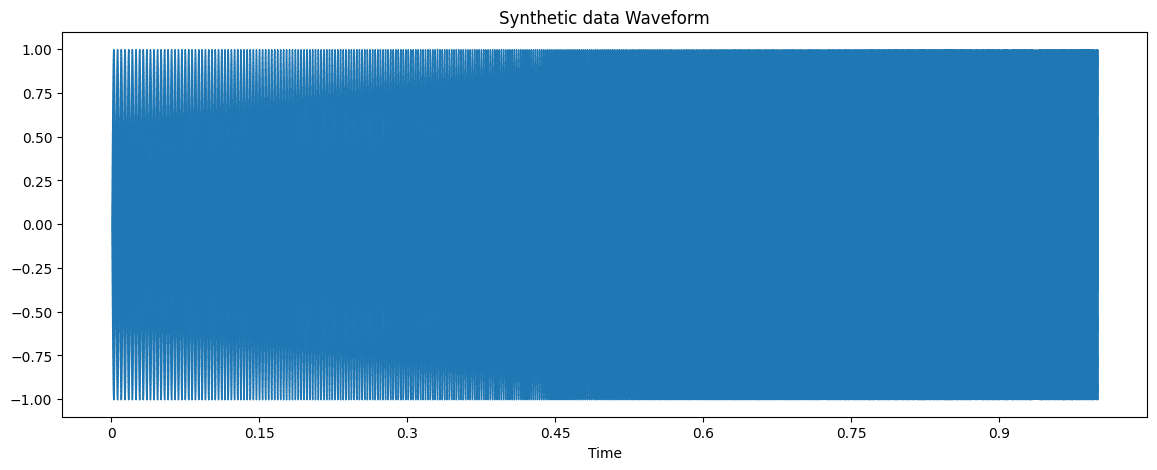

In [2]:
# plot the audio waveform

plt.figure(figsize=(14, 5))
librosa.display.waveshow(y_sweep, sr=sr)
plt.title('Synthetic data Waveform')
plt.show()

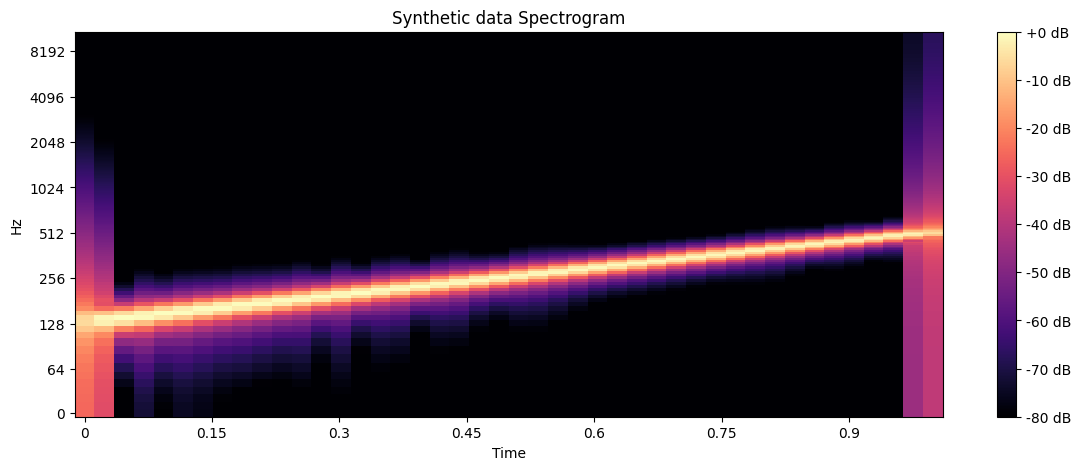

In [ ]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(y_sweep)), ref=np.max)
plt.figure(figsize=(14, 5))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Synthetic data Spectrogram')
plt.show()

In [3]:
# playing a real sound, load audio data
y, sr = librosa.load(librosa.ex('trumpet'))

Audio(data=y, rate=sr)


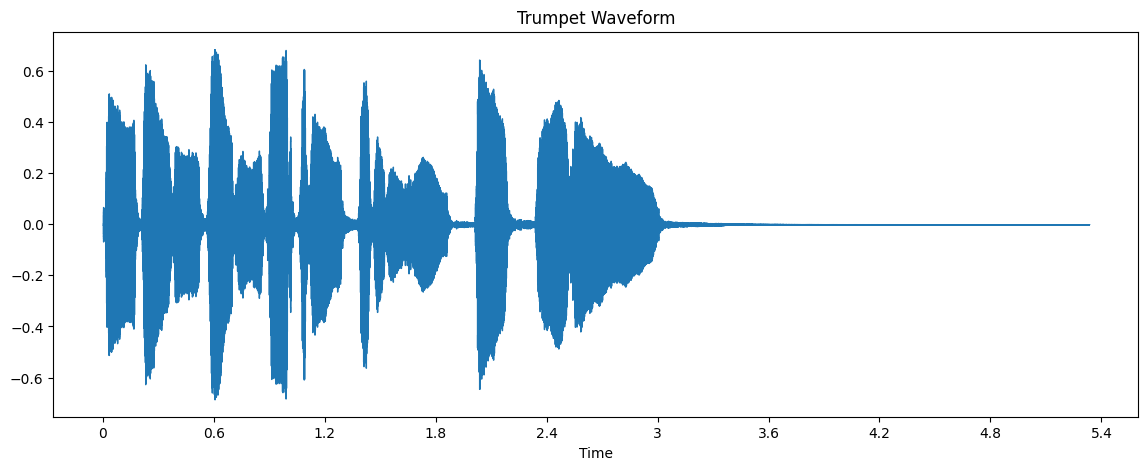

In [ ]:
# plot the audio waveform
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)
plt.title('Trumpet Waveform')
plt.show()

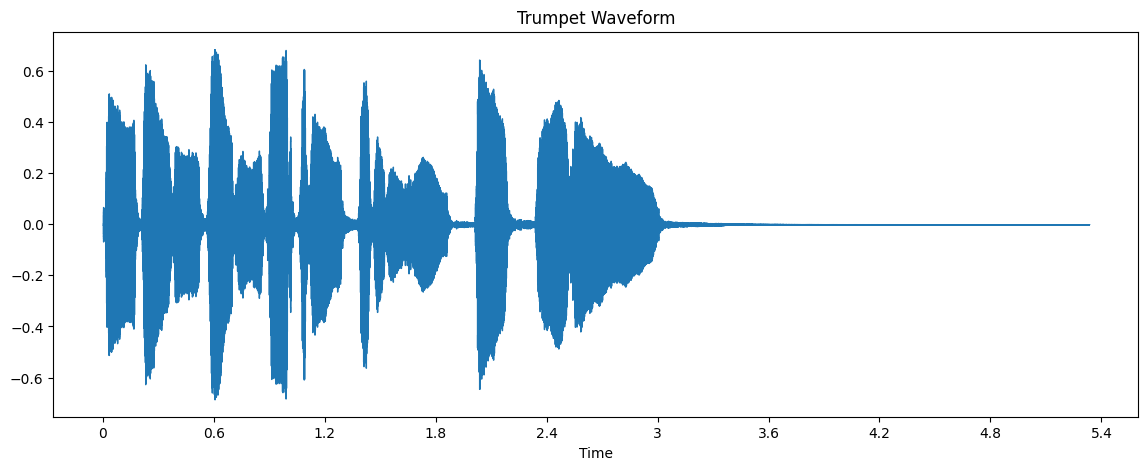

In [ ]:
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)
plt.title('Trumpet Waveform')
plt.show()

In [5]:
y1, sr1 = librosa.load('10Organ.wav')

Audio(data=y1, rate=sr1)

# Task 2: Spectrogram


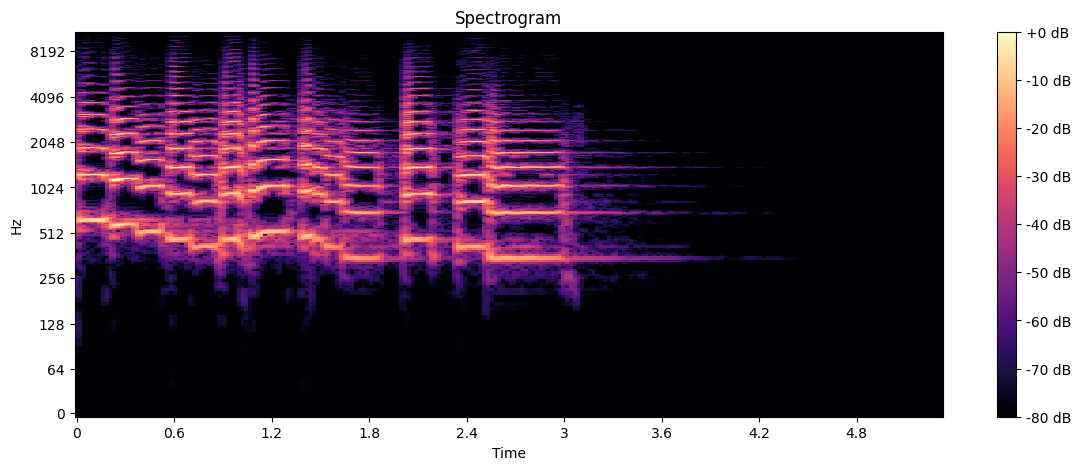

In [ ]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
plt.figure(figsize=(14, 5))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Trumpet Spectrogram')
plt.show()

<ipython-input-16-8eabdfe88f1c>:4: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  spec_db = librosa.amplitude_to_db(spec, ref = np.max)


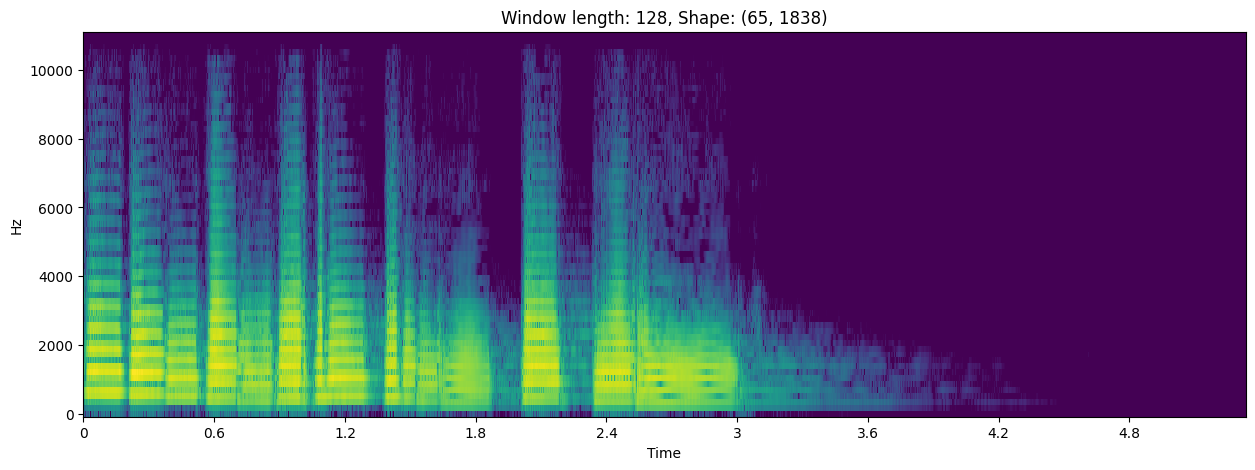

In [ ]:
win_length = 128
hop_length = win_length // 2
spec = librosa.stft(y, n_fft = win_length, hop_length = hop_length)
spec_db = librosa.amplitude_to_db(spec, ref = np.max)
# show plot
plt.figure(figsize=(15, 5))
plt.title('Window length: ' + str(win_length) + ', Shape: ' + str(spec_db.shape))
librosa.display.specshow(spec_db,
                          sr=sr,
                          hop_length=hop_length,
                          x_axis='time',
                          y_axis='hz',
                          cmap=plt.get_cmap('viridis'))

# Task 3: trimmed


In [ ]:
trimmed=librosa.effects.trim(y)
print('original shape', y.shape)
print('trimmed shape', trimmed[0].shape)



# Task 4: MFCC


In [ ]:
# MFCC Feature of audio signal

# Extract MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print(mfccs.shape)

(13, 230)


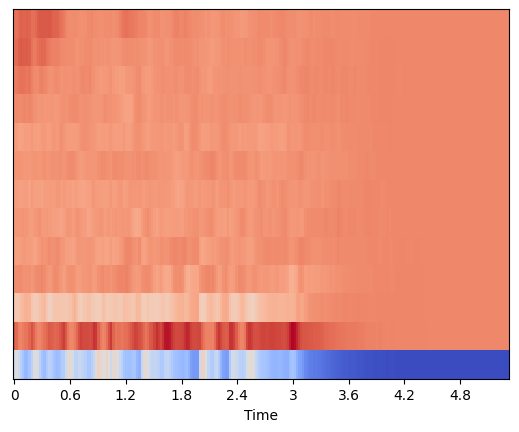

In [ ]:
librosa.display.specshow(mfccs, sr=sr, x_axis='time')